# Session 2: Homework 1

**Author:** Maksim Gorbuk

**Date:** 25 August 2026

In [1]:
!pip install -q skimpy
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 # numpy is a comprehensive library with several mathematical functions
import yfinance as yf              # yfinance fetches stock data directly from Yahoo finance for use in projects
from datetime import datetime      # library with tools for manipulating & handling dates/times
import matplotlib.cm as cm         # colour palettes for visuals
import matplotlib.ticker as mtick  # used in building visuals
import warnings                    # this is used to control how warnings are handled in our project
from skimpy import skim            # Used for generating summary statistics of DataFrames


warnings.filterwarnings('ignore')  # we have decided to suppress all warning messages for this project

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# Analysis of movies- IMDB dataset

We will look at a subset sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
# Load movies data

from pathlib import Path

RAW = "https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data"
local = Path("../data/movies.csv")

movies = pd.read_csv(local if local.exists() else f"{RAW}/movies.csv")



# Printing out information of the dataset

print(movies.info())


# Printing the first few observations of the dataset

movies.head()

skim(movies)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                2961 non-null   object 
 1   genre                2961 non-null   object 
 2   director             2961 non-null   object 
 3   year                 2961 non-null   int64  
 4   duration             2961 non-null   int64  
 5   gross                2961 non-null   int64  
 6   budget               2961 non-null   int64  
 7   cast_facebook_likes  2961 non-null   int64  
 8   votes                2961 non-null   int64  
 9   reviews              2961 non-null   int64  
 10  rating               2961 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 254.6+ KB
None


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2961   │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column      ┃ NA ┃ NA % ┃ mean     ┃ sd       ┃ p0   ┃ p25      ┃ p50      ┃ p75      ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ year        │  0 │    0 │     2003 │    9.946 │ 1920 │     1999 │     2004 │     2010 │      2016 │     ▃█ │  │
│ │ duration    │  0 │    0 │    109.6 │    22.17 │   37 │       95 │      106 │      119 │       330 │  ▁█▁   │  │
│ │ gross       │  0 │    0 │ 58090000 │ 72470000 │  703 │ 12280000 │ 34700000 │ 75590000 │ 760500000 │   █▁   │  │
│ │ budget      │  0 │    0 │ 40620000 │ 43680000 │  218 │ 11000000 │ 26000000 │ 55000000 │ 300000000 │  █▂▁   │  │
│ │ cast_facebo │  0 │    0 │    12390 │    20530 │    0 │     2241 │     4604 │    16930 │    656700 │   █    │  │
│ │ ok_likes    │    │      │          │          │      │          │          │          │           │        │  │
│ │ votes       │  0 │    0 │   109300 │   158100 │    5 │    19920 │    55750 │   133300 │   1690000 │   █▁   │  │
│ │ reviews     │  0 │    0 │    503.3 │    493.7 │    2 │      199 │      364 │      631 │      5312 │   █▁   │  │
│ │ rating      │  0 │    0 │    6.389 │    1.052 │  1.6 │      5.8 │      6.5 │      7.1 │       9.3 │   ▂█▆▁ │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────┴──────────┴──────────┴──────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃          ┃    ┃      ┃          ┃           ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column   ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ title    │  0 │    0 │ O        │ Borat:    │ 10         │ xXx:      │       15.3 │       2.8 │       8262 │  │
│ │          │    │      │          │ Cultural  │ Cloverfiel │ State of  │            │           │            │  │
│ │          │    │      │          │ Learnings │ d Lane     │ the Union │            │           │            │  │
│ │          │    │      │          │ of        │            │           │            │           │            │  │
│ │          │    │      │          │ America   │            │           │            │           │            │  │
│ │          │    │      │          │ for Make  │            │           │            │           │            │  │
│ │          │    │      │          │ Benefit   │       

Besides the obvious variables of title, genre, director, year, and duration, the rest of the variables are as follows:

- gross : The gross earnings in the US box office, not adjusted for inflation

- budget: The movie's budget

- cast_facebook_likes: the number of facebook likes cast memebrs received

- votes: the number of people who voted for (or rated) the movie in IMDB

- reviews: the number of reviews for that movie

- rating: IMDB average rating

## Use your data import, inspection, and cleaning skills to answer the following:

### Missing values and duplicates

Are there any missing values (NAs)? Are all entries distinct or are there duplicate entries?

In [3]:
# Missing values and duplicates

# Missing values, column by column.
print("Missing values per column:")
print(movies.isna().sum())
print(f"\nTotal missing values: {movies.isna().sum().sum()}")

# Duplicates. Two different questions:
#   1. identical rows,
#   2. the same film entered twice with a small difference somewhere.
print(f"\nFully identical rows: {movies.duplicated().sum()}")

dup_mask = movies.duplicated(subset=["title", "director", "year"], keep=False)
print(f"Rows sharing title + director + year: {dup_mask.sum()} "
      f"({movies[dup_mask]['title'].nunique()} distinct films)")

# What actually differs between two copies of the same film?
example = movies[movies["title"] == "Alice in Wonderland"]
print("\nExample of a duplicated film:")
example

Missing values per column:
title                  0
genre                  0
director               0
year                   0
duration               0
gross                  0
budget                 0
cast_facebook_likes    0
votes                  0
reviews                0
rating                 0
dtype: int64

Total missing values: 0

Fully identical rows: 0
Rows sharing title + director + year: 107 (53 distinct films)

Example of a duplicated film:


,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
37,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306320,1187,6.5
38,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306336,1187,6.5


There are no missing values anywhere in the dataset. All 11 columns are complete across the 2,961 rows, which is unusual for scraped data and probably means the file was cleaned before we got it.

Duplicates are less obvious. Running `movies.duplicated().sum()` gives 0, so no two rows are completely identical, and it would be easy to stop there and say all entries are distinct. But if you only compare the columns that actually identify a film, which are title, director and year, you find 54 duplicate rows covering 53 films. One of them, Home, appears three times.

Looking at two copies of the same film, the only thing that differs is the number of votes: 306,320 against 306,336 for Alice in Wonderland. That looks like the same IMDB page being scraped twice a few minutes apart rather than two different films.

This matters because those films would otherwise be counted twice in every genre count, director total and average below, so we drop them before doing any of the analysis.

In [4]:
# Keep one row per film before doing any aggregation.
movies_clean = movies.drop_duplicates(subset=["title", "director", "year"], keep="first")

print(f"Rows before: {len(movies)}  |  after: {len(movies_clean)}  |  removed: {len(movies) - len(movies_clean)}")

Rows before: 2961  |  after: 2907  |  removed: 54


### Count of movies by genre

Produce a table with the count of movies by genre, ranked in descending order.

In [5]:
# Count of movies by genre

genre_counts = (
    movies_clean["genre"]
    .value_counts()                       # already sorted descending
    .reset_index(name="movies")
)

# Sanity check: the counts must add back up to the number of films.
assert genre_counts["movies"].sum() == len(movies_clean)

genre_counts

,genre,movies
0,Comedy,844
1,Action,719
2,Drama,484
3,Adventure,281
4,Crime,198
5,Biography,135
6,Horror,128
7,Animation,35
8,Fantasy,26
9,Documentary,25


Comedy (844), Action (719) and Drama (484) make up just over 70% of the sample. At the other end five genres have fewer than five films each, and Thriller has only one, so any statistic for those groups is meaningless. That is why the plots later on filter them out.

It is also worth noticing that each film here has exactly one genre, while IMDB normally gives a film several. Something like Deadpool is action, comedy and adventure at the same time, but this dataset has picked one label. So the genre groups are cruder than they look.

### Average gross, budget, and return on budget by genre

Produce a table with the average gross earning and budget (gross and budget) by genre. Calculate a variable return_on_budget which shows how many dollars did a movie make at the box office for each dollar of its budget. Rank genres by this return_on_budget in descending order.

In [6]:
# Average gross, budget, and return on budget by genre

genre_money = (
    movies_clean
    .groupby("genre")
    .agg(
        films=("title", "size"),
        mean_gross=("gross", "mean"),
        mean_budget=("budget", "mean"),
    )
)

# Return on budget: box-office dollars earned per dollar spent.
# Computed as (average gross / average budget), so one freak film cannot
# dominate the genre. See the note below on why that choice matters.
genre_money["return_on_budget"] = genre_money["mean_gross"] / genre_money["mean_budget"]

genre_money.sort_values("return_on_budget", ascending=False).round(2)

,films,mean_gross,mean_budget,return_on_budget
genre,,,,
Musical,2,9.208400e+07,3189500.00,28.87
Family,3,1.491605e+08,14833333.33,10.06
Western,2,2.082188e+07,3465000.00,6.01
Documentary,25,1.735397e+07,5887852.44,2.95
Horror,128,3.778231e+07,13804378.74,2.74
Fantasy,26,4.190267e+07,18484615.38,2.27
Comedy,844,4.248781e+07,24458505.74,1.74
Mystery,15,6.911714e+07,41500000.00,1.67
Animation,35,9.843379e+07,61701428.57,1.60


The top of this table is misleading. Musical shows a return of 28.9, Family 10.1 and Western 6.0, but those genres have two, three and two films in them. One lucky film sets the whole number.

The first result that means anything is Horror at 2.74 across 128 films. Horror films are cheap to make, with an average budget of $13.8m against $70.8m for Action, and they earn back a lot relative to that. Action is at the bottom of the credible range at 1.22, so the huge budgets are only just being covered on average.

There is also a choice hidden in the wording of the question. "How many dollars did a movie make for each dollar of its budget" can mean the ratio of the averages, or the average of the ratios for each film. These are not the same. For Horror the first gives 2.74 and the second gives 86.2. The difference comes almost entirely from Paranormal Activity, which cost $15,000 and made $107.9m, a ratio of about 7,195. Averaging the ratios lets that one film outweigh the other 127. I used the ratio of the averages because it answers the question a studio would ask, which is how much the genre earned for every dollar the genre spent.

### Top 15 directors by gross revenue

Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director.

In [7]:
# Top 15 directors by gross revenue

top_directors = (
    movies_clean
    .groupby("director")["gross"]
    .agg(["sum", "mean", "median", "std", "count"])
    .sort_values("sum", ascending=False)
    .head(15)
    .round(0)
)

top_directors

,sum,mean,median,std,count
director,,,,,
Steven Spielberg,4014061704,174524422.0,164435221.0,101421051.0,23
Michael Bay,2195443511,182953626.0,168468240.0,125789167.0,12
James Cameron,1909725910,318287652.0,175562880.0,309171337.0,6
Christopher Nolan,1813227576,226653447.0,196667606.0,187224133.0,8
George Lucas,1741418480,348283696.0,380262555.0,146193880.0,5
Robert Zemeckis,1619309108,124562239.0,100853835.0,91300279.0,13
Tim Burton,1557078534,111219895.0,69791834.0,99304293.0,14
Sam Raimi,1443167519,180395940.0,138480208.0,174705230.0,8
Clint Eastwood,1378321100,72543216.0,46700000.0,75487408.0,19


Ranking directors by total gross rewards making a lot of films as much as making successful ones. Spielberg is top with $4.01bn, but that is across 23 films. George Lucas only made five and averages $348m per film, which is the highest average in the table, and James Cameron made six at $318m.

The standard deviation column is the interesting one. Cameron's is $309m, which is larger than his own median, because Avatar and Titanic are far above everything else he did. Spielberg's mean and median are close together at $175m and $164m, which suggests consistently large films rather than one or two outliers.

### Ratings distribution by genre

Finally, ratings. Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.

In [8]:
# Ratings distribution by genre

ratings_by_genre = (
    movies_clean
    .groupby("genre")["rating"]
    .agg(["min", "max", "median", "mean", "std", "count"])
    .sort_values("mean", ascending=False)
    .round(2)
)

ratings_by_genre

,min,max,median,mean,std,count
genre,,,,,,
Biography,4.5,8.9,7.20,7.11,0.76,135
Crime,4.8,9.3,6.90,6.92,0.85,198
Mystery,4.6,8.5,6.70,6.84,0.91,15
Musical,6.3,7.2,6.75,6.75,0.64,2
Drama,2.1,8.8,6.80,6.74,0.92,484
Documentary,1.6,8.5,7.40,6.66,1.77,25
Sci-Fi,5.0,8.2,6.40,6.66,1.09,7
Animation,4.5,8.0,6.90,6.65,0.97,35
Romance,6.2,7.1,6.65,6.65,0.64,2


Keeping 12 of 17 genres (2897 of 2907 films)


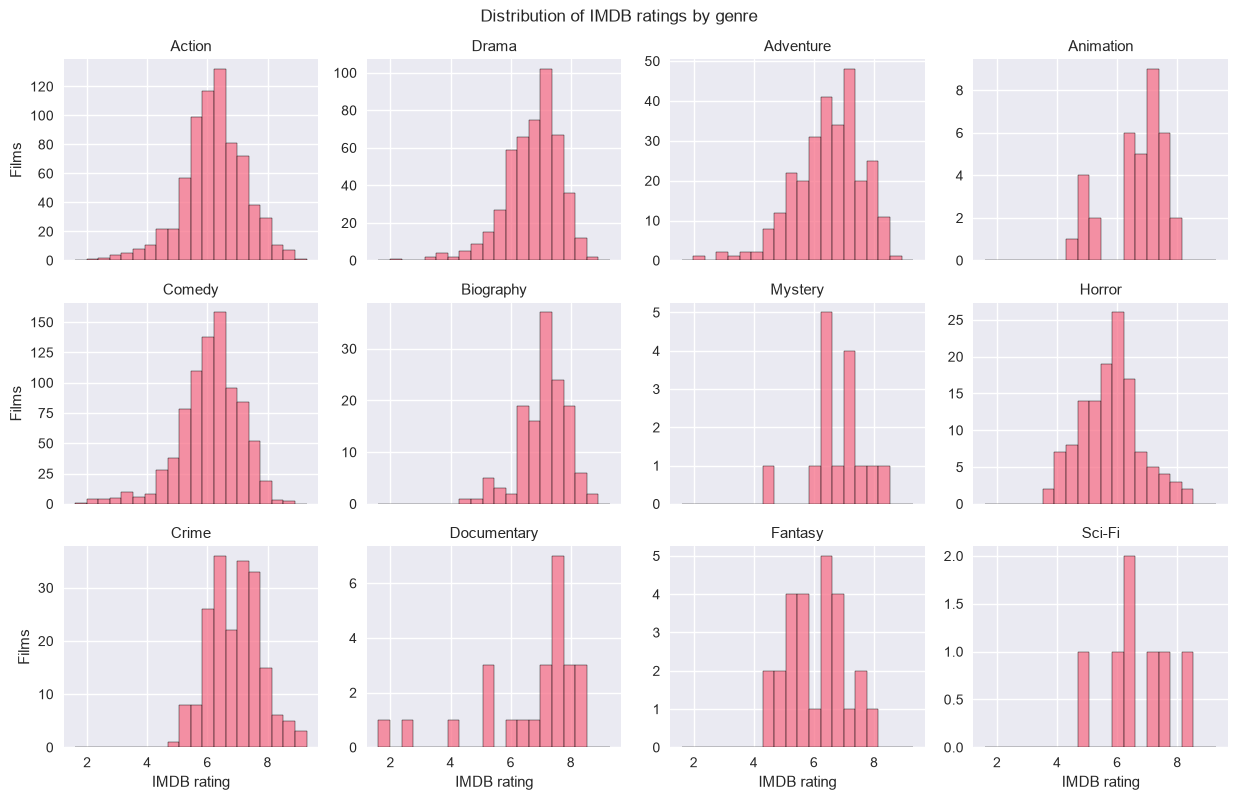

In [9]:
# Histogram of ratings by genre

# Filter for genres that have at least 5 movies: a density curve drawn through
# one or two points describes nothing.
genre_sizes = movies_clean["genre"].value_counts()
big_genres = genre_sizes[genre_sizes >= 5].index

ratings_plot_data = movies_clean[movies_clean["genre"].isin(big_genres)]
print(f"Keeping {len(big_genres)} of {len(genre_sizes)} genres "
      f"({len(ratings_plot_data)} of {len(movies_clean)} films)")

# Plot all the histograms together instead of one after another, using
# seaborn's FacetGrid via displot.
g = sns.displot(
    data=ratings_plot_data,
    x="rating",
    col="genre",
    col_wrap=4,
    bins=20,
    height=2.6,
    aspect=1.2,
    facet_kws={"sharey": False},   # genres differ hugely in size
)
g.set_titles("{col_name}")
g.set_axis_labels("IMDB rating", "Films")
g.figure.suptitle("Distribution of IMDB ratings by genre", y=1.02)
plt.show()

Ratings sit in quite a narrow band. Every genre with a reasonable number of films averages somewhere between 5.8 and 7.1, so genre does not explain very much about how a film is rated.

Biography rates highest with a mean of 7.11 and Horror lowest at 5.79. The spread is as interesting as the average. Documentary has a standard deviation of 1.77, much wider than anything else, and a range from 1.6 to 8.5, so people either rate documentaries very highly or not at all.

Action and Comedy, which are the two biggest genres, sit near the bottom at 6.23 and 6.11.

The std column for Thriller shows NaN because there is only one film in that group, and you cannot measure spread from a single observation.

## Use `seaborn` to answer the following:

### Gross vs. cast Facebook likes

-   Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?

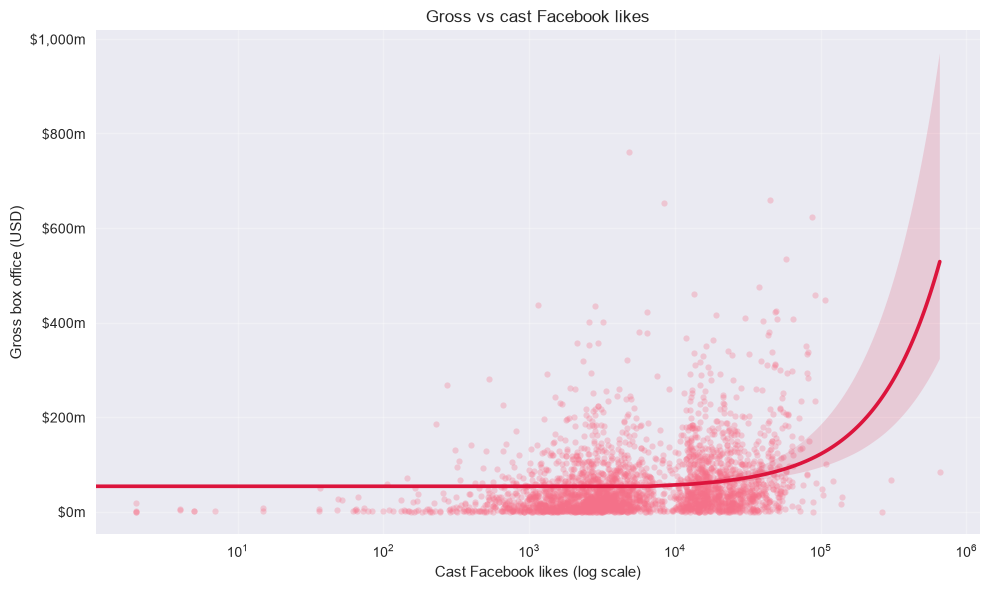

Correlation between gross and cast facebook likes: 0.208


In [10]:
# Scatter plot: Gross vs Cast Facebook Likes

# gross goes on the Y axis because it is the outcome we would want to predict;
# cast_facebook_likes goes on X because it is the candidate predictor.
plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies_clean,
    x="cast_facebook_likes",
    y="gross",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "crimson"},
)

plt.xscale("log")          # likes span several orders of magnitude
plt.xlabel("Cast Facebook likes (log scale)")
plt.ylabel("Gross box office (USD)")
plt.title("Gross vs cast Facebook likes")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Correlation Calculation ---
correlation = movies_clean["gross"].corr(movies_clean["cast_facebook_likes"])

print(f"Correlation between gross and cast facebook likes: {correlation:.3f}")

Gross goes on the Y axis and Facebook likes on the X axis, because we are asking whether likes can predict revenue and the thing being predicted normally goes on Y.

The correlation is 0.21, which is positive but weak. The scatter is basically a shapeless cloud: at any level of Facebook likes there are films that made almost nothing and films that made hundreds of millions. So the number of likes the cast has is not a good predictor of box office on its own.

There is also a timing problem. The Facebook likes were counted when the data was collected, which is years after most of these films came out, so a star's follower count partly reflects how successful their films were rather than causing it.

### Gross vs. budget

-   Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.

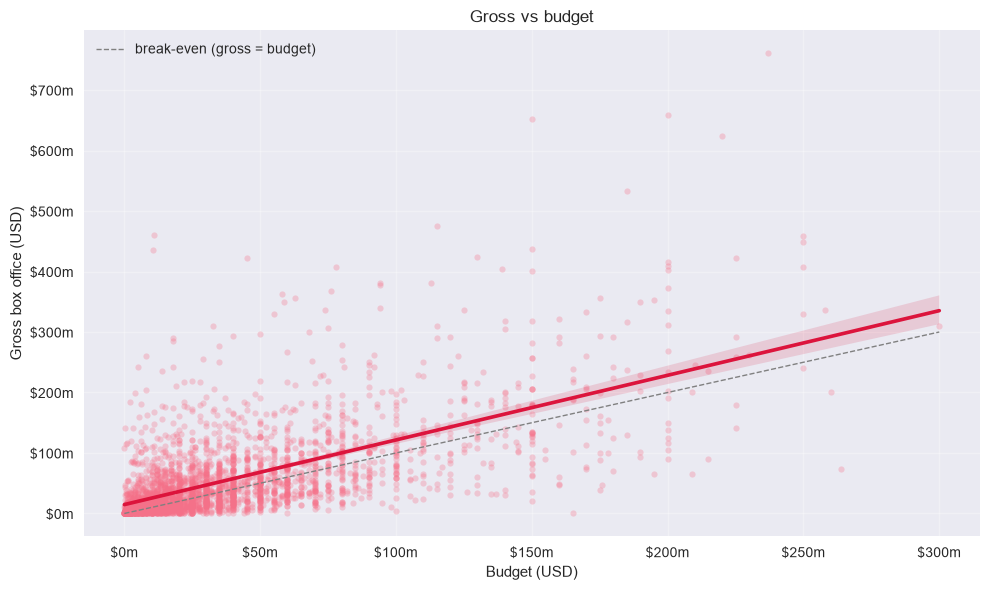

Correlation between gross and budget: 0.639
Films grossing less than their budget: 42%


In [11]:
# Scatter plot: Gross vs Budget

plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies_clean,
    x="budget",
    y="gross",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "crimson"},
)

# Break-even line: everything below it lost money at the box office.
lims = [0, movies_clean["budget"].max()]
plt.plot(lims, lims, linestyle="--", color="grey", linewidth=1, label="break-even (gross = budget)")
plt.legend()

plt.xlabel("Budget (USD)")
plt.ylabel("Gross box office (USD)")
plt.title("Gross vs budget")
fmt = mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m")
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().yaxis.set_major_formatter(fmt)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_budget = movies_clean["gross"].corr(movies_clean["budget"])
loss_share = (movies_clean["gross"] < movies_clean["budget"]).mean()

print(f"Correlation between gross and budget: {corr_budget:.3f}")
print(f"Films grossing less than their budget: {loss_share:.0%}")

Budget is the best predictor of the three, with a correlation of 0.64, and you can actually see the relationship in the plot rather than having to take it on trust.

Two things stop it being a rule though. The spread gets wider as budgets get bigger, so expensive films are not just better on average, they are also more variable, producing both the biggest hits and the biggest failures. And 42% of the films here grossed less than their budget, which is what the dashed break-even line shows.

It is also not clear which way the causation runs. Studios spend a lot on films they already expect to sell, like sequels or films with big stars, so some of what looks like spending buying revenue is really expected revenue justifying the spending.

### Gross vs. rating, faceted by genre

-   Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?

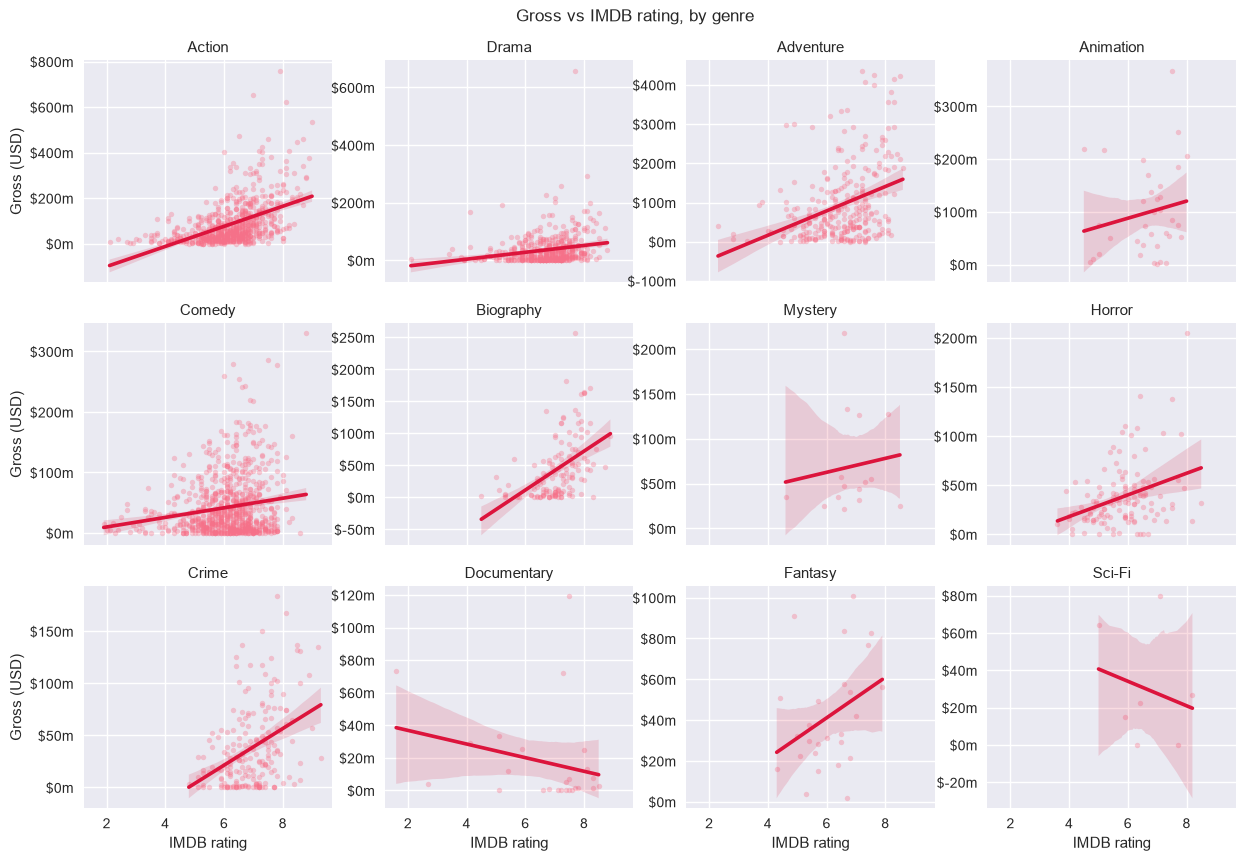

Overall correlation between gross and rating: 0.274


In [12]:
# Scatter plot: Gross vs Rating by Genre- for genres that have at least 5 movies

gross_rating_data = movies_clean[movies_clean["genre"].isin(big_genres)]

g = sns.lmplot(
    data=gross_rating_data,
    x="rating",
    y="gross",
    col="genre",
    col_wrap=4,
    height=2.8,
    aspect=1.1,
    scatter_kws={"alpha": 0.35, "s": 15},
    line_kws={"color": "crimson"},
    facet_kws={"sharey": False},
)
g.set_titles("{col_name}")
g.set_axis_labels("IMDB rating", "Gross (USD)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m"))
g.figure.suptitle("Gross vs IMDB rating, by genre", y=1.02)
plt.show()

print(f"Overall correlation between gross and rating: "
      f"{movies_clean['gross'].corr(movies_clean['rating']):.3f}")

The correlation between rating and gross is 0.27, which is weak, and the facets show it is not even consistent from genre to genre. Action, Adventure and Animation slope upwards fairly clearly, while Documentary and Mystery are flat or slope down. Being well reviewed and making money are close to unrelated, which makes some sense once you remember that a rating is an average of opinions from people who already chose to watch the film.

A few things about this dataset are strange:

1. Each film has only one genre, even though IMDB gives films several. That makes every comparison by genre rougher than it looks.
2. The genre groups are very unbalanced, with 844 comedies and one thriller. Five genres had to be dropped before plotting and Sci-Fi only just survives with seven films.
3. There are the 54 duplicate records found earlier, identical apart from a few votes, which suggests the file was put together by scraping.
4. Gross is not adjusted for inflation, as the data dictionary says, but the films run from 1920 to 2016. A dollar in 1975 is not a dollar in 2015, so older films are understated.
5. Gross looks like US box office only, so films that made most of their money abroad are undercounted, which also affects the return on budget table.

# Returns of financial stocks

> You may find useful the material on [finance data sources](https://am01-sep24.netlify.app/reference/finance_data/).

We will use the `yfinance` package to download historical data of stock prices, calculate returns, and examine the distribution of returns.

We must first identify which stocks we want to download data for, and for this we must know their ticker symbol; Apple is known as AAPL, Microsoft as MSFT, McDonald's as MCD, etc. The file `nyse.csv` contains 508 stocks listed on the NYSE, their ticker `symbol`, `name`, the IPO (Initial Public Offering) year, and the sector and industry the company is in.



In [13]:
# Load NYSE data

# Load the dataset from the relevant directory


from pathlib import Path

RAW = "https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data"
local = Path("../data/nyse.csv")


nyse = pd.read_csv(local if local.exists() else f"{RAW}/nyse.csv")


# Printing out the first 10 observations
nyse.head()

# Printing out information of the dataset's variables
print("nData info: ")

nyse.info()

nData info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   symbol         508 non-null    object 
 1   name           508 non-null    object 
 2   ipo_year       143 non-null    float64
 3   sector         508 non-null    object 
 4   industry       508 non-null    object 
 5   summary_quote  508 non-null    object 
dtypes: float64(1), object(5)
memory usage: 23.9+ KB


## Companies per sector

Based on this dataset, create a table and a bar plot that shows the number of companies per sector, in descending order

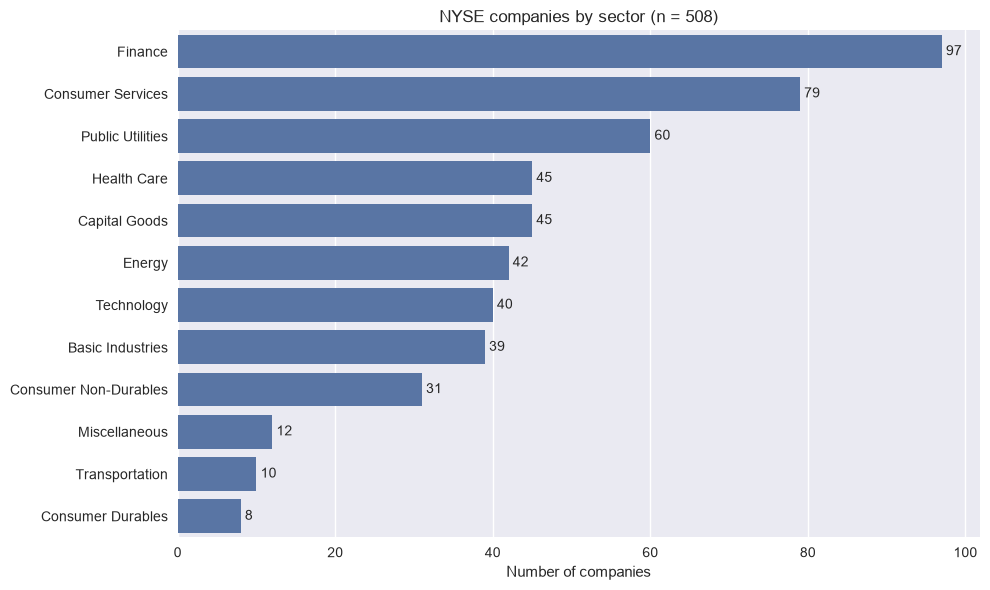

In [14]:
# Companies per sector

# value_counts() counts the rows in each sector and already sorts them descending.
sector_counts = (
    nyse["sector"]
    .value_counts()
    .reset_index(name="companies")
)

sector_counts


# Bar plot
# Sectors go on the y-axis: the names are long and would overlap horizontally.
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sector_counts, x="companies", y="sector", color="#4C72B0")
ax.bar_label(ax.containers[0], padding=3, fontsize=10)
ax.set(
    xlabel="Number of companies",
    ylabel="",
    title=f"NYSE companies by sector (n = {sector_counts['companies'].sum()})",
)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## Choose stocks and download data

Next, let's choose some stocks and their ticker symbols and download some data. You **MUST** choose 6 different stocks from the ones listed below; You should, however, add `SPY` which is the SP500 ETF (Exchange Traded Fund).

In [15]:
# Download stock data

# The 6 chosen stocks plus SPY (the S&P 500 ETF)
my_stocks = ["AAPL", "JPM", "DIS", "DPZ", "ANF", "XOM", "SPY"]

# Date range: start on 1 January five years ago, end today.
end_date = pd.Timestamp.today().normalize()
start_date = pd.Timestamp(year=end_date.year - 5, month=1, day=1)

# Download all the tickers in one call. Passing a list gives back a frame with
# two levels of columns (field, ticker), so we pick "Adj Close" to get a simple
# table of prices: dates on the rows, one column per stock.
prices = yf.download(
    my_stocks,
    start=start_date,
    end=end_date,
    auto_adjust=False,   # keep the explicit "Adj Close" column
    progress=False,
)["Adj Close"]

# yfinance sorts the columns alphabetically, so put them back in our order.
prices = prices[my_stocks]

print(f"Downloaded {start_date.date()} to {end_date.date()}")
print("Adjusted-close price matrix:", prices.shape)   # (trading days, stocks)
prices.head()

Downloaded 2021-01-01 to 2026-08-25
Adjusted-close price matrix: (1416, 7)


Ticker,AAPL,JPM,DIS,DPZ,ANF,XOM,SPY
Date,,,,,,,
2021-01-04,125.632515,109.000519,172.271988,352.244019,20.490000,33.251328,342.436859
2021-01-05,127.185783,109.593636,173.008835,353.951935,21.370001,34.853809,344.795410
2021-01-06,122.904526,114.739685,173.668167,357.228302,22.240000,35.743179,346.856781
2021-01-07,127.098427,118.507637,173.144608,355.668945,21.209999,36.023598,352.010223
2021-01-08,128.195450,118.638474,173.251236,360.903931,21.530001,36.424217,354.015808


## Calculate daily and monthly returns

Financial performance analysis depend on returns; If I buy a stock today for 100 and I sell it tomorrow for 101.75, my one-day return, assuming no transaction costs, is 1.75%. So given the adjusted closing prices, our first step is to calculate daily and monthly returns.

In [16]:
# Calculate returns

# pct_change() on the whole DataFrame computes returns for every stock at once.
daily_returns = prices.pct_change()

# Resample to month-end ("ME") / year-end ("YE"), take the last price in each
# period, then compute the percentage change. (Older pandas uses "M" / "Y".)
monthly_returns = prices.resample("ME").last().pct_change()
yearly_returns  = prices.resample("YE").last().pct_change()

monthly_returns.head()

Ticker,AAPL,JPM,DIS,DPZ,ANF,XOM,SPY
Date,,,,,,,
2021-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-28,-0.079712,0.143779,0.124101,-0.065406,0.186389,0.233125,0.027805
2021-03-31,0.007339,0.034382,-0.023910,0.064204,0.253562,0.026853,0.045400
2021-04-30,0.076218,0.016330,0.008129,0.148318,0.092684,0.025255,0.052910
2021-05-31,-0.050497,0.067811,-0.039620,0.010726,0.138970,0.034597,0.006566


## Summary of monthly returns

Create a table where you summarise monthly returns for each of the stocks and `SPY`; min, max, median, mean, SD.

In [17]:
# Summary of monthly returns

# .agg() applies all five statistics to every column in one shot; .T puts the
# stocks on the rows and the statistics on the columns.
monthly_summary = (
    monthly_returns
    .agg(["min", "max", "median", "mean", "std"])
    .T
    .round(4)
)

print("Monthly returns summary:")
monthly_summary

Monthly returns summary:


,min,max,median,mean,std
Ticker,,,,,
AAPL,-0.1223,0.1886,0.0175,0.0157,0.0711
JPM,-0.1484,0.2154,0.0234,0.0196,0.0680
DIS,-0.1861,0.2487,-0.0107,-0.0016,0.0935
DPZ,-0.1944,0.1773,-0.0027,0.0044,0.0925
ANF,-0.4089,0.4226,0.0487,0.0376,0.1680
XOM,-0.1291,0.2692,0.0253,0.0259,0.0803
SPY,-0.0924,0.1051,0.0210,0.0129,0.0439


## Density plot of monthly returns

Plot a density plot, using `sns.kdeplot()`, for each of the stocks

Text(0.5, 1.02, 'Density of Monthly Returns by Stock')

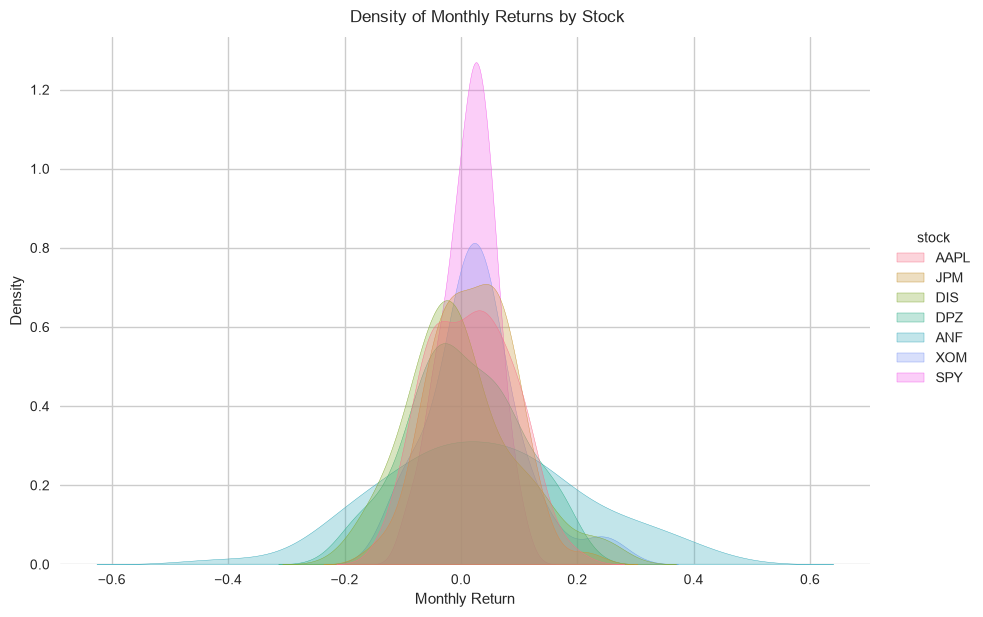

In [18]:
# Density plot of monthly returns

# Reshape to long ("tidy") form so seaborn can colour by stock with `hue`:
# one row per (date, stock, monthly_return).
monthly_long = (
    monthly_returns
    .melt(value_name="monthly_return", var_name="stock", ignore_index=False)
    .dropna()
)

sns.set_style("whitegrid")

# displot draws every stock's KDE on a single seaborn figure, no manual loop.
g = sns.displot(
    data=monthly_long,
    x="monthly_return",
    hue="stock",
    kind="kde",
    fill=True,
    alpha=0.3,
    height=6,
    aspect=1.5,
)
g.set_axis_labels("Monthly Return", "Density")
g.fig.suptitle("Density of Monthly Returns by Stock", y=1.02)

What can you infer from this plot? Which stock is the riskiest? The least risky?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

The density plot helps us understand the distribution of monthly returns over the observed period. It allows us to compare the volatility of the stocks and identify the ranges where their monthly returns are most concentrated.

ANF appears to be the riskiest stock because it has the broadest distribution of monthly returns. Its actual monthly returns run from -40.9% to +42.3%, and the smoothed curve spreads wider still. Its standard deviation is 16.8%, roughly twice that of the next widest stock. This indicates that ANF experienced greater fluctuations than the other assets.

The S&P 500 index fund appears to be the least risky asset, with a standard deviation of 4.4% and returns only ranging from -9.2% to +10.5%. Its average monthly return over the period was 1.29%. This suggests that its monthly returns were more concentrated and less volatile.

DIS has its highest density at a slightly negative monthly return, with a median of -1.07%. This suggests that its most common monthly return was below zero during the observed period. However, this does not mean DIS produced a loss on average or followed a bearish trend throughout the period. The mean return and cumulative return would need to be examined before drawing such conclusions. Its mean is in fact -0.16%, which is close to flat rather than clearly negative.

The remaining stocks appear to be more volatile than SPY but less volatile than ANF, and their density peaks generally occur at positive monthly returns. This is consistent with the intuition that an index fund generally has lower volatility than an individual stock because SPY holds shares in many companies whose price movements offset one another.

## Risk-return plot

Finally, make a plot that shows the expected monthly return (mean) of a stock on the Y axis and the risk (standard deviation) in the X-axis. Please use `plt.annotate()` to label each stock

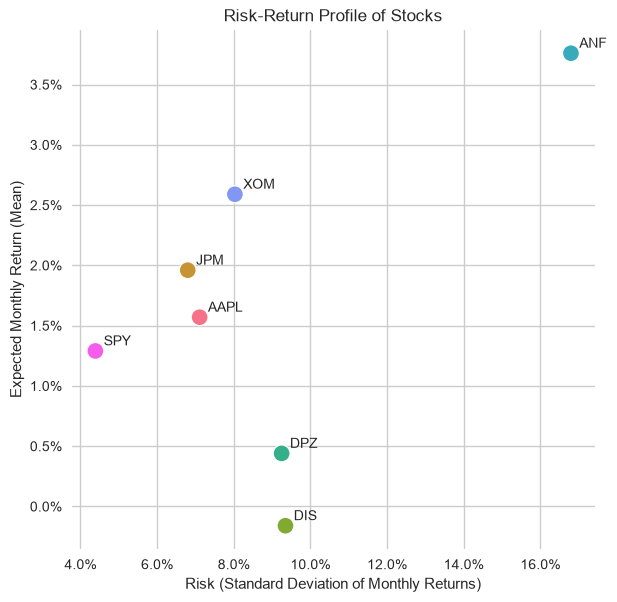

In [19]:
# Risk-return plot
# monthly_summary already holds each stock's mean (return) and std (risk),
# so we can plot straight from it. reset_index turns the ticker into a column.
risk_return = monthly_summary.reset_index(names="stock")

sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=risk_return,
    x="std",
    y="mean",
    hue="stock",
    s=150,
    legend=False,
)

# Label each point, one annotation per row.
for row in risk_return.itertuples():
    ax.annotate(row.stock, (row.std, row.mean),
                xytext=(6, 4), textcoords="offset points")

ax.set(
    xlabel="Risk (Standard Deviation of Monthly Returns)",
    ylabel="Expected Monthly Return (Mean)",
    title="Risk-Return Profile of Stocks",
)

# Format both axes as percentages with one decimal (values are decimals, so xmax=1).
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

What can you infer from this plot? Are there any stocks which, while being riskier, do not have a higher expected return?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE

You would expect the points to run from the bottom left to the top right, meaning that more risk comes with more return. That is roughly what happens for some of them. ANF sits far to the right with a standard deviation of 16.8%, but it also has the highest average monthly return at 3.76%, so the extra risk did pay off here. XOM and JPM sit in the middle on both measures.

Two stocks clearly break the pattern.

DIS has a standard deviation of 9.35%, more than double SPY's, and an average monthly return of -0.16%. So investors took on twice the risk of the market and ended up slightly worse off than doing nothing.

DPZ is almost the same story. Its risk is 9.25%, again about double SPY's, and its average return is only 0.44%, well below the 1.29% you would have got from just holding the index.

A simple way to compare them is to divide the mean by the standard deviation, which gives return per unit of risk: XOM 0.32, SPY 0.29, JPM 0.29, ANF 0.22, AAPL 0.22, DPZ 0.05, DIS -0.02. Only XOM beat the index on this measure, and only by a small margin. Four of the six individual stocks did worse than simply buying SPY, which is the practical case for diversification.

One thing to keep in mind is that this is only 67 monthly observations from one particular five-year window, so the averages are noisy. A different start date would probably reorder the middle of the list. The risk ranking tends to be more stable across periods than the return ranking.

# Rents in San Francisco 2000-2018

[Kate Pennington](https://www.katepennington.org/data) created a panel of historic Craigslist rents by scraping posts archived by the Wayback Machine. You can read more about her work here:

[What impact does new housing have on rents, displacement, and gentrification in the surrounding neighborhood? Read our interview with economist Kate Pennington about her article, \"Does Building New Housing Cause Displacement?:The Supply and Demand Effects of Construction in San Francisco.\"](https://matrix.berkeley.edu/research-article/kate-pennington-on-gentrification-and-displacement-in-san-francisco/)

In our case, we have a clean(ish) dataset with about 200K rows that correspond to Craigslist listings for renting properties in the greater SF area. The data dictionary is as follows:

| variable    | class     | description           |
|-------------|-----------|-----------------------|
| post_id     | character | Unique ID             |
| date        | double    | date                  |
| year        | double    | year                  |
| nhood       | character | neighborhood          |
| city        | character | city                  |
| county      | character | county                |
| price       | double    | price in USD          |
| beds        | double    | n of beds             |
| baths       | double    | n of baths            |
| sqft        | double    | square feet of rental |
| room_in_apt | double    | room in apartment     |
| address     | character | address               |
| lat         | double    | latitude              |
| lon         | double    | longitude             |
| title       | character | title of listing      |
| descr       | character | description           |
| details     | character | additional details    |

The dataset was used in a recent [tidyTuesday](https://github.com/rfordatascience/tidytuesday) project.

In [20]:
# Download rent data

rent = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-07-05/rent.csv')

print("Data shape:", rent.shape)

print("\nData info:")

# Printing the dataset's variables, their data types etc.
print(rent.info())

Data shape: (200796, 17)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), objec

## Variable types and missing values

What are the variable types? Do they all correspond to what they really are? Which variables have most missing values?

In [21]:
# Data inspection

# Calculating the total no. of missing values in each column of the dataset


# Sorts variables with missing values in ascending order

# Printing out the datatypes


# Printing out a sample- the first few rows



## Top 20 cities by % of listings

Make a plot that shows the top 20 cities in terms of % of classifieds between 2000-2018. You need to calculate the number of listings by city, and then convert that number to a %.

The final graph should look like this:

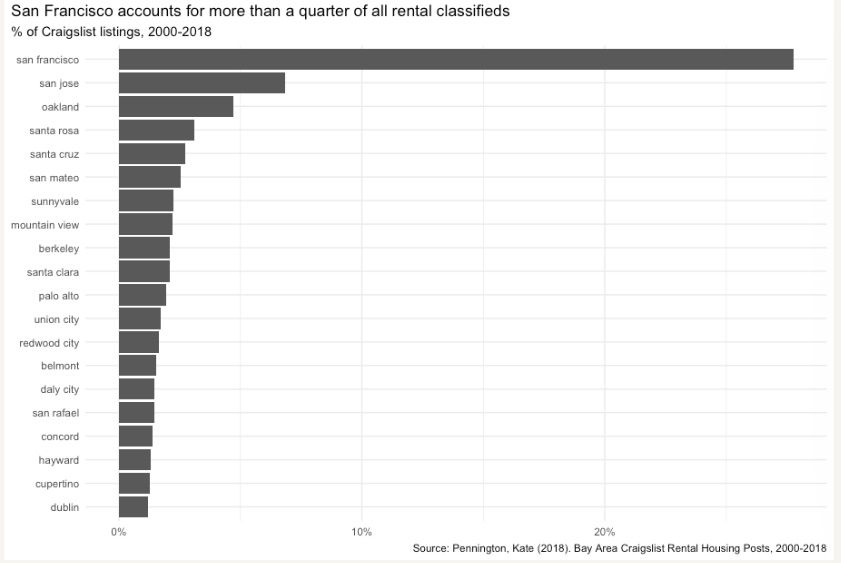

In [22]:
# Top 20 cities by percentage of listings



## Median prices in San Francisco by bedrooms

Make a plot that shows the evolution of median prices in San Francisco for 0, 1, 2, and 3 bedrooms listings. The final graph should resemble this

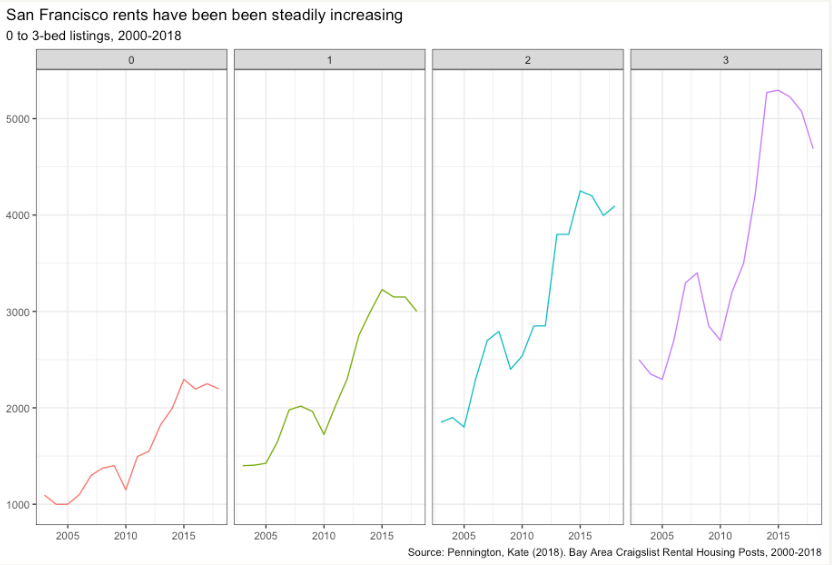

In [23]:
# Time-series of median rents in San Francisco (0-3 bedrooms)

# Data Prep



## Median rents for the top 12 Bay Area cities

Finally, make a plot that shows median rental prices for the top 12 cities in the Bay area (for 1 bedroom rentals). Your final graph should look like this

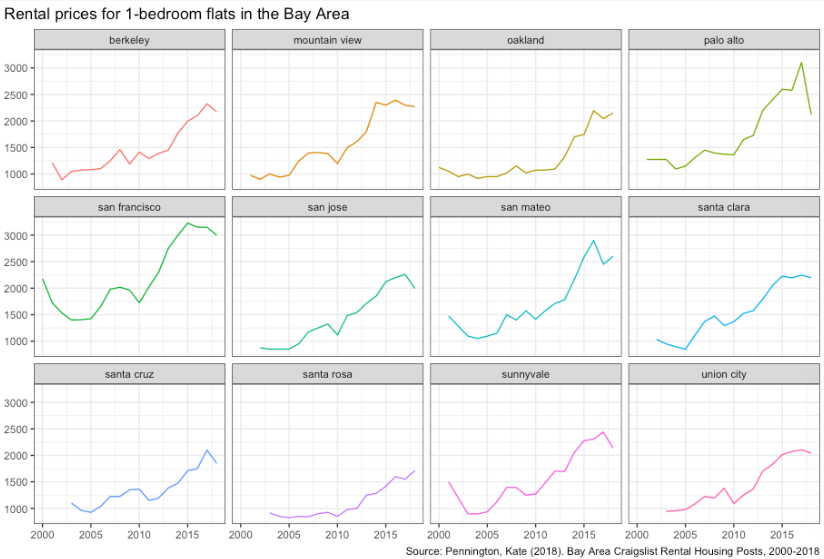

In [24]:
# Median rental prices for top 12 cities (in terms of number of ads) in Bay Area



What can you infer from these plots? Don't just explain what's in the graph, but speculate or tell a short story (1-2 paragraphs max).

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

# Deliverables

There is a lot of explanatory text, comments, etc. You do not need these, so delete them and produce a stand-alone document that you could share with someone. Save this notebook and upload it to Canvas.

# Details

-   Who did you collaborate with: Ben (we went through the stocks section together; the write-up of the density plot is his)
-   Approximately how much time did you spend on this problem set: around 6 hours, including getting the environment working
-   What, if anything, gave you the most trouble: getting VS Code to use the project's .venv instead of the system Python, which kept failing on SSL certificates. After that, deciding how to define return on budget, since the ratio of averages and the average of ratios give very different answers.


**Please seek out help when you need it,** and remember the 15-minute rule. You know enough Python (and have enough examples of code from class and your readings) to be able to do this. If you get stuck, ask for help from others, use LLMs at your own risk-- and remember that I am here to help too!

> As a true test to yourself, do you understand the code you submitted and are you able to explain it to someone else?


# Rubric

Check minus (1/5): Displays minimal effort. Doesn't complete all components. Code is poorly written and not documented. Uses the same type of plot for each graph, or doesn't use plots appropriate for the variables being analyzed.

Check (3/5): Solid effort. Hits all the elements. No clear mistakes. Easy to follow (both the code and the output)